In [9]:
import pandas as pd
import baseline_simulator
from utils import *

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
tou = np.ones((96,)) * 17.5  # off-peak cents/kWh
tou[64:84] = 36.7  # 4 pm - 9 pm peak
tou[36:56] = 14.9  # 9 am - 2 pm super off-peak
TOU = np.concatenate([tou, tou, tou]) # wrap around for multi-day sessions

In [10]:
sessions_df = pd.read_csv("/Users/sam/Desktop/StationLevelPowerForecasting/data/Sessions3.csv")
sessions_df = sessions_df.sort_values(by='startChargeTime')

test_df = sessions_df[(pd.to_datetime(sessions_df['connectTime']).dt.year == 2024) & (pd.to_datetime(sessions_df['connectTime']).dt.month == 1)]
test_df = test_df[test_df['DurationHrs'] > 0.5]
test_df = test_df[test_df['cumEnergy_Wh'] > 0]
test_df['choice'] = 'SCHEDULED'
sim = baseline_simulator.BaselineSimulator(test_df, verbose=True, flexibility_constant=0.5)

In [14]:
COST_DC = 2000

power_profiles, prices, hourly_prices = sim.simulate()

---------------------------------------------------------------------
Done with optimization at 2024-01-02 10:11:14
Optimal prices (per kW): (30, 40)
Optimal prices (per hour): (96.05714285714285, 264.0)
Probabilities [0.48691265 0.20330041 0.30978693]
Utilities [ 0.6072 -0.2662  0.155 ]
Optimized delivery of 16.81 kW to session #6671
Number of active sessions: 1
Current peak options 3.2 6.6
Running DC options 3.2 6.6
Peak thus far 3.2
Profit options [1359.97277035] [2885.84999831] [0.]
new_sch_obj -241.40817856774845
new_reg_obj -414.15000000000003
existing_sch_obj 0.0
existing_reg_obj 0
Profit 1248.8824460252322
---------------------------------------------------------------------
Done with optimization at 2024-01-03 00:58:06
Optimal prices (per kW): (20, 40)
Optimal prices (per hour): (61.333333333333336, 264.0)
Probabilities [0.70527156 0.08742514 0.2073033 ]
Utilities [ 1.2144 -0.8734 -0.01  ]
Optimized delivery of 9.2 kW to session #6674
Number of active sessions: 1
Current peak 

In [22]:
DELTA_T = 0.25

agg_power_profile_all_sch = aggregate_power_profiles(test_df, power_profiles, DELTA_T)
profit_all_sch = get_profit(test_df, power_profiles, prices, DELTA_T, TOU)
profit_all_sch - COST_DC * max(agg_power_profile_all_sch), max(agg_power_profile_all_sch)

(104385.60402274062, 27.859540391124156)

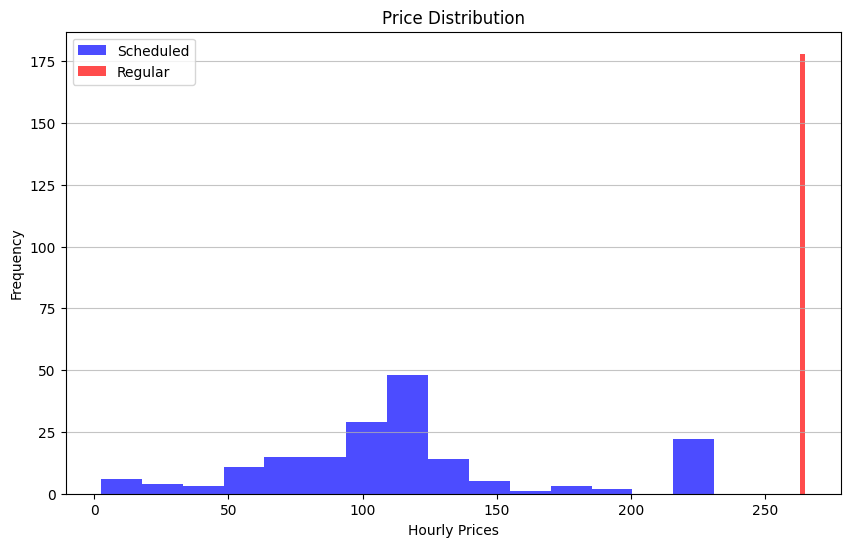

In [42]:
import matplotlib.pyplot as plt

values_index_0 = [value[0] for value in hourly_prices.values()]
values_index_1 = [value[1] for value in hourly_prices.values()]

plt.figure(figsize=(10, 6))

plt.hist(values_index_0, bins=15, alpha=0.7, color='blue', label="Scheduled")
plt.hist(values_index_1, bins=[263, 265], alpha=0.7, color='red', label="Regular")

plt.xlabel("Hourly Prices")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.legend()

plt.grid(axis='y', alpha=0.75)
plt.show()


In [5]:
from scipy.special import softmax

power_rate = 6.6

# Default discrete choice model parameters
dcm_charging_sch_params = np.array(
[[-power_rate * 0.0184 / 2], [power_rate * 0.0184 / 2], [0], [0]]
)
dcm_charging_reg_params = np.array(
[[power_rate * 0.0184 / 2], [-power_rate * 0.0184 / 2], [0], [0.341]]
)
dcm_leaving_params = np.array(
[[power_rate * 0.005 / 2], [power_rate * 0.005 / 2], [0], [-1]]
)
theta = np.vstack((dcm_charging_sch_params.T, dcm_charging_reg_params.T, dcm_leaving_params.T))


zk = [60, 70, 1, 1]
vk = softmax(theta @ zk).flatten()#.reshape(3,1)
vk

array([0.31951277, 0.13340602, 0.54708121])

In [11]:
zk = [1000, 1000, 1, 1]
vk = softmax(theta @ zk).flatten()#.reshape(3,1)
vk

array([1.26641655e-14, 1.78102903e-14, 1.00000000e+00])

In [12]:
theta, zk

(array([[-0.06072,  0.06072,  0.     ,  0.     ],
        [ 0.06072, -0.06072,  0.     ,  0.341  ],
        [ 0.0165 ,  0.0165 ,  0.     , -1.     ]]),
 [1000, 1000, 1, 1])